# 1. 주제 및 데이터셋 선택  

STL-10 다중 클래스 분류

스탠포드 대학교 , 출처 : https://cs.stanford.edu/~acoates/stl10/  
데이터 유형 : 이미지  
문제 유형 : 다중 분류  
예측할 클래스 수 : 10개  
(비행기, 새, 자동차, 고양이, 사슴, 개, 말, 원숭이, 배, 트럭)  
해상도 : 96x96x3  
학습 데이터셋 5000개  
테스트 데이터셋 8000개  

In [30]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from tqdm.auto import tqdm

In [31]:
# Colab 환경(linux)에서 폰트 다운받고 한글 패치
!apt-get update -qq
!apt-get install -qq fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [32]:
!ls data

stl10_binary  stl10_binary.tar.gz


In [33]:
!ls

data  sample_data


In [34]:
# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# cuda -> GPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

3. STL-10 데이터 불러오기

- 이미지를 Tensor로 변환, 크기 통일(224x224), 픽셀값 정규화
- 학습 데이터에만 증강 적용 (train_transform), 검증/테스트는 정규화만 적용 (eval_transform)
- 데이터가 이미 받아져 있으면 다운로드는 생략

In [35]:
# 기대하는 입력 크기/정규화 통계
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 학습 데이터 전처리 도구 : 데이터 증강 강화(4,000장) + 리사이즈 + Tensor 변환 + 정규화
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # 무작위 영역 잘라 확대 (위치/크기 다양성)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  # 색상 왜곡
    transforms.RandAugment(num_ops=2, magnitude=9),  # 회전/이동/샤프니스 등 다양한 증강을 무작위 조합
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25)  # 이미지 일부를 랜덤하게 지워 특정 부위 의존 방지
])
# 검증 / 테스트 데이터 전처리 도구 : 증강 없이 리사이즈 + Tensor 변환 + 정규화
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [36]:
# 데이터가 이미 받아져 있으면(추출된 stl10_binary 폴더 존재) 다운로드 생략
DATA_ROOT = "./data"
need_download = not os.path.exists("./data/stl10_binary"))

# 학습용 STL-10 데이터셋 (증강 적용)
full_train_dataset_aug = datasets.STL10(
    root=DATA_ROOT,
    split='train',
    download=need_download,
    transform=train_transform
)
# 검증용으로 사용할 학습 데이터셋 (증강 미적용, 위와 동일한 원본에서 인덱스만 나눠 사용)
full_train_dataset_eval = datasets.STL10(
    root=DATA_ROOT,
    split='train',
    download=need_download,
    transform=eval_transform
)
# 최종 평가용 테스트 데이터셋
test_dataset = datasets.STL10(
    root=DATA_ROOT,
    split='test',
    download=need_download,
    transform=eval_transform
)

print(f"전체 학습 데이터 수 : {len(full_train_dataset_aug)}")
print(f"테스트 데이터 수 : {len(test_dataset)}")

전체 학습 데이터 수 : 5000
테스트 데이터 수 : 8000


4. Train / Valid 데이터 분리 (클래스 층화)

- STL-10 train은 클래스당 정확히 500장 10개 클래스 비율을 유지
- 데이터가 4,000장으로 적은 편이라 학습 데이터를 최대한 확보하기 위해 valid 비중을 8:2로 설정
- train : 모델 가중치 학습용 (증강 적용)
- valid : EarlyStopping / Scheduler 판단용 (증강 미적용)
- test : 학습 종료 후 최종 성능 평가용 (증강 미적용, 학습 중 절대 사용 금지)

In [37]:
all_labels = full_train_dataset_aug.labels

# 클래스 비율을 유지하며 train/valid 인덱스 분리 (8:2)
train_indices, valid_indices = train_test_split(
    np.arange(len(all_labels)),
    test_size=0.2,
    stratify=all_labels,
    random_state=SEED
)

train_dataset = Subset(full_train_dataset_aug, train_indices)   # 증강 적용한 학습 데이터셋
valid_dataset = Subset(full_train_dataset_eval, valid_indices)  # 증강 없는 검증 데이터셋

print(f"학습 데이터 수 : {len(train_dataset)}, 검증 데이터 수 : {len(valid_dataset)}, 테스트 데이터 수 : {len(test_dataset)}")

학습 데이터 수 : 4000, 검증 데이터 수 : 1000, 테스트 데이터 수 : 8000


5. 클래스 분포 확인

- Target(클래스) 분포 및 클래스 불균형 여부 확인
- STL-10은 원래 클래스당 이미지 수가 균등(train 500장, test 800장)해서 불균형 문제는 없음

In [38]:
class_names = full_train_dataset_aug.classes  # ['airplane', 'bird', 'car', ...]

train_labels = all_labels[train_indices]
valid_labels = all_labels[valid_indices]
test_labels = test_dataset.labels

label_df = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts().sort_index(),
    "valid": pd.Series(valid_labels).value_counts().sort_index(),
    "test": pd.Series(test_labels).value_counts().sort_index(),
})
label_df.index = class_names

label_df

,train,valid,test
airplane,400,100,800
bird,400,100,800
car,400,100,800
cat,400,100,800
deer,400,100,800
dog,400,100,800
horse,400,100,800
monkey,400,100,800
ship,400,100,800
truck,400,100,800


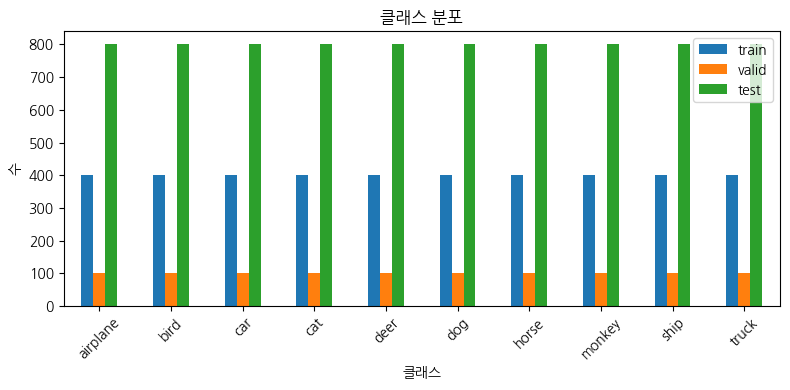

In [39]:
label_df.plot(kind='bar', figsize=(8, 4))
plt.title("클래스 분포")
plt.xlabel("클래스")
plt.ylabel("수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. DataLoader 구성

- train / valid / test 각각의 DataLoader 생성, batch_size 설정
- 학습 데이터에만 shuffle=True 적용
- 배치 하나를 꺼내 이미지/라벨 shape 확인 : [batch_size, channel, height, width], [batch_size]

In [40]:
BATCH_SIZE = 16  # 224x224 컬러 이미지라 GPU 메모리 고려해 작게 유지

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 미니배치 하나를 꺼내서 형태 확인
images, labels = next(iter(train_loader))
print(f"images.shape : {images.shape}, labels.shape : {labels.shape}")

images.shape : torch.Size([16, 3, 224, 224]), labels.shape : torch.Size([16])


7. 이미지 데이터 확인

- 클래스별 샘플 이미지를 직접 시각화해 라벨이 맞는지, 밝기/색상/형태에 이상이 없는지 확인

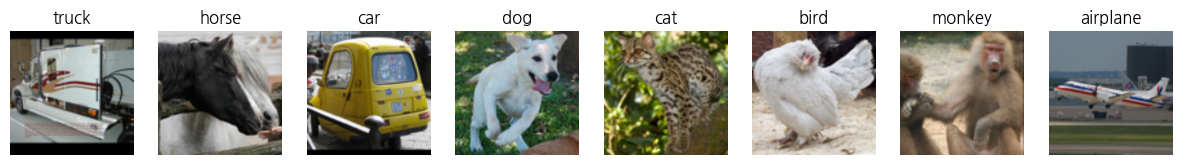

In [41]:
# 역정규화 함수 : 시각화를 위해 ImageNet 정규화를 원래 범위(0~1)로 되돌림
def denormalize(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor * std + mean
    return image.clamp(0, 1)

def show_images(dataset, n=10):

    plt.figure(figsize=(15, 4))

    for i in range(n):
        image, label = dataset[i]
        image = denormalize(image).permute(1, 2, 0)  # (C,H,W) -> (H,W,C)

        plt.subplot(1, n, i + 1)
        plt.imshow(image)
        plt.title(f"{class_names[label]}")
        plt.axis("off")

    plt.show()

show_images(valid_dataset, 8)

8. CNN 모델 정의

- Conv - BatchNorm - ReLU - MaxPool 블록을 반복해 채널을 늘리고 크기를 줄여가며 특징을 추출, Dropout으로 과적합 완화
- 다중 분류이므로 출력 노드는 클래스 수(10개), 출력층에 별도 활성화 함수는 두지 않음 (Softmax는 CrossEntropyLoss 내부에서 처리)

In [42]:
# num_classes = len(class_names)  # 10
#
# model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
#
# # backbone 전체 freeze (사전학습된 특징 추출기 그대로 사용)
# for param in model.features.parameters():
#     param.requires_grad = False
#
# # 마지막 conv 블록만 unfreeze (STL-10 도메인에 맞춰 미세조정)
# for param in model.features[-1].parameters():
#     param.requires_grad = True
#
# # 분류기 교체 : 10개 클래스 출력 + Dropout으로 과적합 완화
# model.classifier = nn.Sequential(
#     nn.Dropout(0.3),
#     nn.Linear(model.classifier[1].in_features, num_classes)
# )
#
# model = model.to(device)
# model

# 사전학습 가중치 없이 직접 설계한 CNN
num_classes = len(class_names)  # 10

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Conv Block : Conv -> BatchNorm -> ReLU -> MaxPool 반복하며 채널은 늘리고 크기는 절반씩 축소
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    # 224x224x3 -> 224x224x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                # 112x112x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                # 56x56x64

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                # 28x28x128

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                # 14x14x256
        )

        # 입력 크기에 상관없이 채널별 평균 1개 값만 남겨 FC 입력 크기를 고정
        self.avgpool = nn.AdaptiveAvgPool2d(1)               # -> 1x1x256

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

model = CustomCNN(num_classes).to(device)
model

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

9. 손실함수, 최적화함수, Scheduler 설정

- 다중 분류이므로 CrossEntropyLoss 사용
- Optimizer(AdamW), Learning Rate, Weight Decay 설정
- ReduceLROnPlateau로 valid_loss 정체 시 학습률 자동 감소

In [43]:
# 다중 클래스 분류용 손실함수
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# freeze된 파라미터는 제외하고 학습 대상 파라미터만 최적화
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.AdamW(
    trainable_params,
    lr=1e-3,           # 학습률
    weight_decay=1e-4  # L2 규제 (과적합 완화)
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",   # valid_loss 기준이라 감소하는 방향
    factor=0.5,   # learning rate 감소율
    patience=2    # 2 epoch 동안 개선 없으면 조정
)

10. EarlyStopping 클래스 정의
- 일정 epoch동안 개선이 없으면 학습 조기종료
- 과적합 완화

In [44]:
class EarlyStopping:

    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience      # 개선을 기다릴 epoch
        self.min_delta = min_delta    # 개선으로 인정할 최소 변화량
        self.best_loss = float("inf")  # 최소 valid loss
        self.counter = 0              # 개선이 없었던 epoch
        self.best_state = None        # 최고 성능 모델 가중치

    def __call__(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

11. 학습함수와 평가 함수 정의

- 학습 : train() 모드 → 기울기 초기화 → 순전파 → 손실 계산 → 역전파 → 가중치 업데이트
- 평가 : eval() 모드 + torch.no_grad()로 기울기 계산 비활성화

In [45]:
# 모델을 1 epoch 학습하는 함수
def train_one_epoch(model, dataloader, criterion, optimizer, device, max_norm=1.0):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in tqdm(dataloader, desc='Train', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)  # Gradient Clipping
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    return avg_loss, avg_acc

In [46]:
# 평가하는 함수
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluate', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_count += batch_size

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    return avg_loss, avg_acc

12. 모델 학습

- Epoch마다 Train Loss와 Valid Loss를 함께 기록
- 둘 다 감소 : 정상적인 학습 / Train만 감소하고 Valid가 증가 : 과적합 가능성

In [47]:
EPOCHS = 30

early_stopping = EarlyStopping(patience=4, min_delta=0.0001)
history = []

for epoch in tqdm(range(EPOCHS), desc="Epoch"):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "lr": current_lr
    })

    print(
        f"Epoch: {epoch + 1} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | "
        f"Learning Rate : {current_lr:.6f}"
    )

    if early_stopping(valid_loss, model):
        print("검증 손실 개선이 이루어지지 않아 EarlyStopping")
        break

early_stopping.restore_best_weights(model)

Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch: 1 | Train Loss: 2.1014 | Train Acc: 0.2095 | Valid Loss: 1.7785 | Valid Acc: 0.3470 | Learning Rate : 0.001000


Train:   0%|          | 0/250 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ab812d0540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ab812d0540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch: 29 | Train Loss: 1.3616 | Train Acc: 0.5690 | Valid Loss: 1.2144 | Valid Acc: 0.6280 | Learning Rate : 0.000250


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch: 30 | Train Loss: 1.3422 | Train Acc: 0.5800 | Valid Loss: 1.2794 | Valid Acc: 0.5970 | Learning Rate : 0.000250


13. 학습 과정 시각화

- 학습 곡선으로 모델이 실제로 학습되고 있는지, 과적합이 발생하는지, Epoch 수가 충분한지, Learning Rate가 적절한지 확인

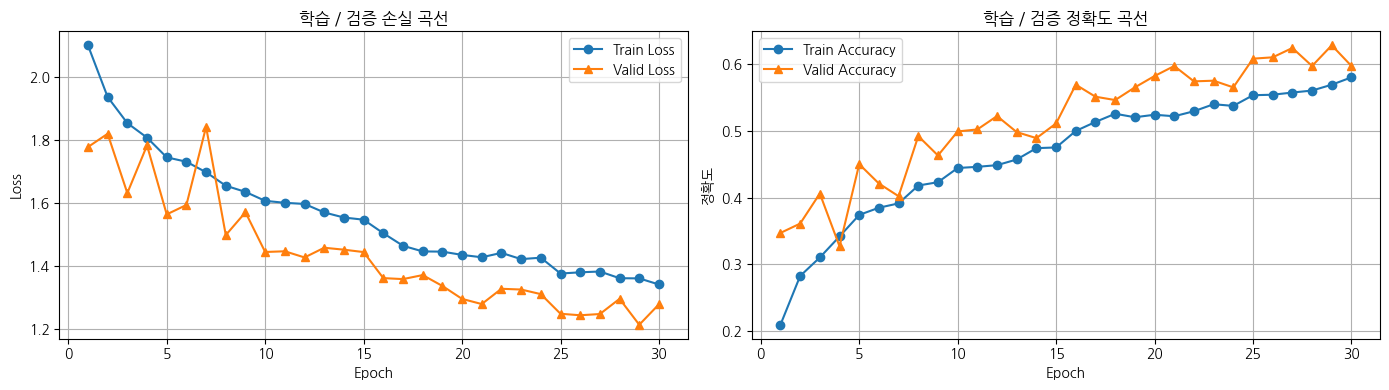

In [48]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label="Train Loss")
axes[0].plot(history_df['epoch'], history_df['valid_loss'], marker='^', label="Valid Loss")
axes[0].set_title("학습 / 검증 손실 곡선")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df['epoch'], history_df['train_acc'], marker='o', label="Train Accuracy")
axes[1].plot(history_df['epoch'], history_df['valid_acc'], marker='^', label="Valid Accuracy")
axes[1].set_title("학습 / 검증 정확도 곡선")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("정확도")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

14. Test 데이터로 최종 평가

- 학습에 전혀 사용되지 않은 Test 데이터로 최종 Accuracy / Loss 평가
- eval() 모드 + no_grad 상태

In [49]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss : {test_loss:.4f}, Test Accuracy : {test_acc:.4f}")

Evaluate:   0%|          | 0/500 [00:00<?, ?it/s]

Test Loss : 1.2040, Test Accuracy : 0.6331


15. 예측 결과 수집 & Confusion Matrix

- Confusion Matrix와 Classification Report(Precision/Recall/F1-Score)로 클래스별 성능 확인
- 어떤 클래스 사이에서 혼동이 많은지 파악

In [50]:
def get_predictions(model, dataloader, device):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Get Predictions', leave=False):
            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            probabilities = torch.softmax(outputs, dim=1)

            y_true.append(labels.numpy())
            y_pred.append(predictions.cpu().numpy())
            y_prob.append(probabilities.cpu().numpy())

    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_prob)

y_true, y_pred, y_prob = get_predictions(model, test_loader, device)

print(y_true[:20])
print(y_pred[:20])

Get Predictions:   0%|          | 0/500 [00:00<?, ?it/s]

[6 7 5 0 3 1 1 1 4 4 0 0 4 0 1 5 4 9 0 6]
[6 1 0 8 5 5 5 1 4 6 0 0 4 0 4 7 4 9 0 6]


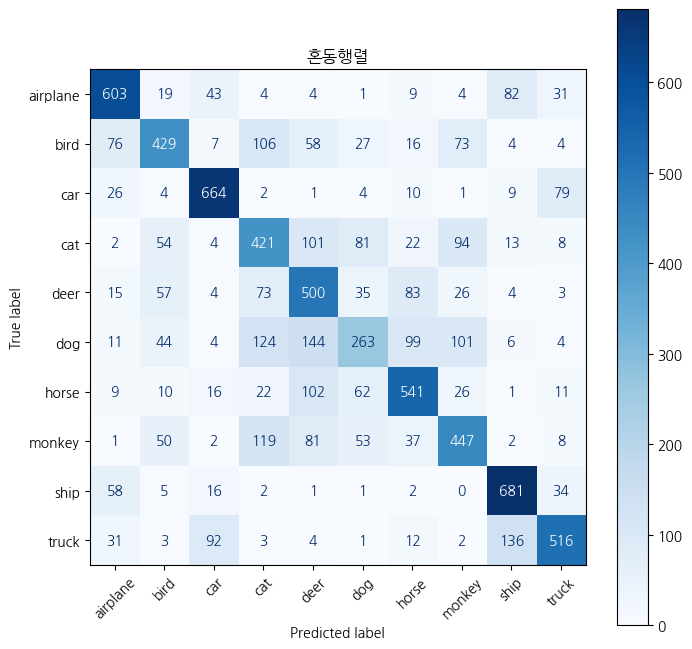

              precision    recall  f1-score   support

    airplane       0.72      0.75      0.74       800
        bird       0.64      0.54      0.58       800
         car       0.78      0.83      0.80       800
         cat       0.48      0.53      0.50       800
        deer       0.50      0.62      0.56       800
         dog       0.50      0.33      0.40       800
       horse       0.65      0.68      0.66       800
      monkey       0.58      0.56      0.57       800
        ship       0.73      0.85      0.78       800
       truck       0.74      0.65      0.69       800

    accuracy                           0.63      8000
   macro avg       0.63      0.63      0.63      8000
weighted avg       0.63      0.63      0.63      8000



In [51]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)
plt.title("혼동행렬")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

16. 오분류 이미지 확인

- 잘못 예측한 이미지와 예측 확률 확인

오분류 개수 : 2935 / 8000


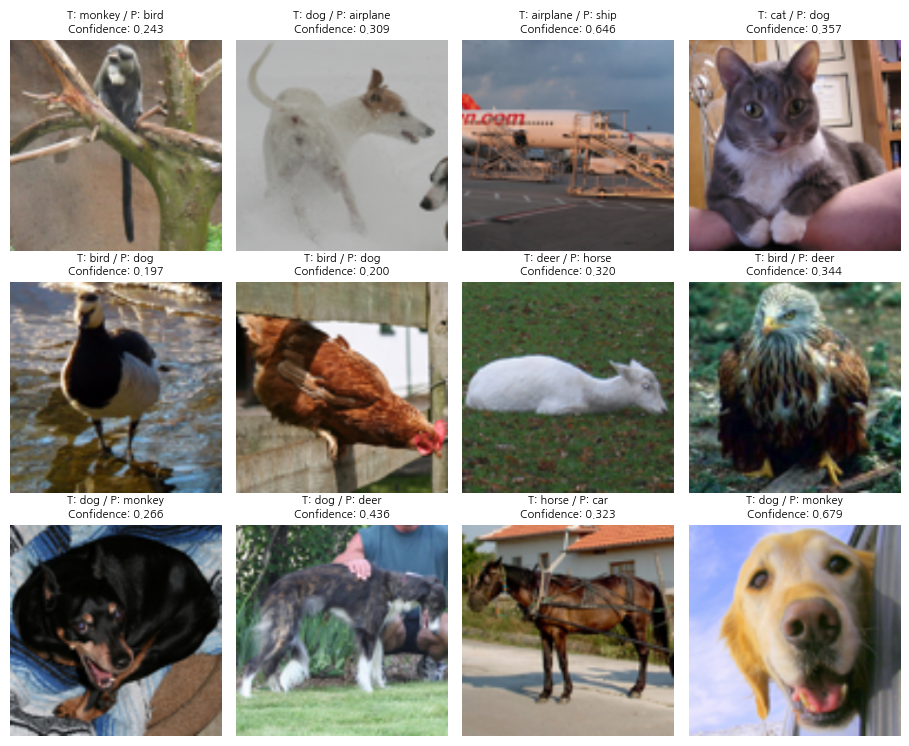

In [52]:
wrong_indices = np.where(y_pred != y_true)[0]
print(f"오분류 개수 : {len(wrong_indices)} / {len(y_true)}")

def show_misclassified(dataset, wrong_indices, y_pred, y_prob, n=12):
    if len(wrong_indices) == 0:
        print("오분류 이미지 없음")
        return

    n = min(n, len(wrong_indices))
    cols = min(4, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.3, rows * 2.5))
    axes = np.array(axes).reshape(-1)

    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]

        image, true_label = dataset[data_idx]
        image_for_plot = denormalize(image).permute(1, 2, 0).numpy()

        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]

        axes[plot_idx].imshow(image_for_plot)
        axes[plot_idx].set_title(
            f"T: {class_names[true_label]} / P: {class_names[pred_label]}\nConfidence: {confidence:.3f}",
            fontsize=8
        )
        axes[plot_idx].axis('off')

    for empty_idx in range(n, len(axes)):
        axes[empty_idx].axis('off')

    plt.tight_layout()
    plt.show()

show_misclassified(test_dataset, wrong_indices, y_pred, y_prob, n=12)